# Load Dataset

In [43]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
url = 'https://raw.githubusercontent.com/jaejeon1/Customer-Churn-Prediction-Model/Portforlio/data/telco.csv'
df = pd.read_csv(url)

print("Shape:", df.shape)
print("\nInfo:")
print(df.info())

Shape: (7043, 50)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                       

In [44]:
#Preview
print(f"Dataset loaded: {df.shape[0]}rows, {df.shape[1]}columns")
df.head()

Dataset loaded: 7043rows, 50columns


,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


# Data Cleaning

In [45]:
#Duplicates
dup_count = df.duplicated().sum()
print(dup_count)

0


In [46]:
#Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_pct = missing_pct.apply(lambda x: f"{x:.1f}%")
print (missing_pct)

Customer ID                           0.0%
Gender                                0.0%
Age                                   0.0%
Under 30                              0.0%
Senior Citizen                        0.0%
Married                               0.0%
Dependents                            0.0%
Number of Dependents                  0.0%
Country                               0.0%
State                                 0.0%
City                                  0.0%
Zip Code                              0.0%
Latitude                              0.0%
Longitude                             0.0%
Population                            0.0%
Quarter                               0.0%
Referred a Friend                     0.0%
Number of Referrals                   0.0%
Tenure in Months                      0.0%
Offer                                55.0%
Phone Service                         0.0%
Avg Monthly Long Distance Charges     0.0%
Multiple Lines                        0.0%
Internet Se

In [47]:
df['Offer'].value_counts(dropna=False)

,count
Offer,
NaN,3877
Offer B,824
Offer E,805
Offer D,602
Offer A,520
Offer C,415


In [48]:
# Proof: Offer

offer_nan_churn = df[df['Offer'].isnull()]['Churn Label'].value_counts(normalize=True)
offer_val_churn = df[df['Offer'].notna()]['Churn Label'].value_counts(normalize=True)

print("Offer ✅:", offer_nan_churn)
print("Offer ❌:", offer_val_churn)

Offer ✅: Churn Label
No     0.728914
Yes    0.271086
Name: proportion, dtype: float64
Offer ❌: Churn Label
No     0.74163
Yes    0.25837
Name: proportion, dtype: float64


In [49]:
df['Offer'] = df['Offer'].fillna('No Offer')

Offer strategy is ineffective

Churn rate is virtually identical whether customers received an offer or not (27% vs 25%).

This suggests current offers lack competitive differentiation.

In [50]:
# Proof: Internet Type

df[df['Internet Type'].isnull()]['Internet Service'].value_counts()

,count
Internet Service,
No,1526


All 1,526 customers with missing value have Internet Service = 'No'

—> Confirmed 100% match

In [51]:
df['Internet Type'] = df['Internet Type'].fillna('No Internet')

In [52]:
# Proof: Churn Category

df[df['Churn Category'].isnull()]['Customer Status'].value_counts()

,count
Customer Status,
Stayed,4720
Joined,454


In [53]:
df['Churn Category'] = df['Churn Category'].fillna('Not Churned')

In [54]:
# Proof: Churn Reason

df[df['Churn Reason'].isnull()]['Customer Status'].value_counts()

,count
Customer Status,
Stayed,4720
Joined,454


In [55]:
df['Churn Reason'] = df['Churn Reason'].fillna('Not Churned')

Churn Category and Churn Reason both follow the same logic.
Values only exist for churned customers
Stayed and Joined customers have no churn category or reason by definition.

This is structural missing, not a data error.
→ Both filled with 'Not Churned'

In [56]:
#Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_pct = missing_pct.apply(lambda x: f"{x:.1f}%")
print (missing_pct)

Customer ID                          0.0%
Gender                               0.0%
Age                                  0.0%
Under 30                             0.0%
Senior Citizen                       0.0%
Married                              0.0%
Dependents                           0.0%
Number of Dependents                 0.0%
Country                              0.0%
State                                0.0%
City                                 0.0%
Zip Code                             0.0%
Latitude                             0.0%
Longitude                            0.0%
Population                           0.0%
Quarter                              0.0%
Referred a Friend                    0.0%
Number of Referrals                  0.0%
Tenure in Months                     0.0%
Offer                                0.0%
Phone Service                        0.0%
Avg Monthly Long Distance Charges    0.0%
Multiple Lines                       0.0%
Internet Service                  

Missing Value Strategy:

---

Step 1 — Classify the type of missing:

Structurally Missing → logically correct to have no value

Randomly Missing     → data collection error

---

Step 2 — Handle each differently:

Structural: fill with meaningful label (e.g. 'No Offer', 'Not Churned')

Random: investigate distribution before deciding

---

Step 3 — Verify before and after treatment

  → Confirm fill values make business sense

  → Check no unintended data distortion

# Data Anlaysis

# 1. Who churns? (Demography)

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Churn Value -> 0/1
df['Churn'] = (df['Customer Status'] == 'Churned').astype(int)

# Churn Rate by Contract
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
print(contract_churn)

Contract
Month-to-Month    0.458449
One Year          0.107097
Two Year          0.025491
Name: Churn, dtype: float64


M2M customers churn at 18x the rate of two-year customers.

In [58]:
# Churn rate by Tenure
df['Tenure Group'] = pd.cut(df['Tenure in Months'],
                             bins=[0, 6, 12, 24, 48, 100],
                             labels=['0-6m', '6-12m', '12-24m', '24-48m', '48m+'])

tenure_churn = df.groupby('Tenure Group', observed=False)['Churn'].mean()
print(tenure_churn)

Tenure Group
0-6m      0.533333
6-12m     0.353352
12-24m    0.287109
24-48m    0.203890
48m+      0.095132
Name: Churn, dtype: float64


The first 6 months are the danger zone.
Customers who survive past 2 years are largely loyal which means retention efforts should be front-loaded, not spread evenly.

In [59]:
# Senior Citizen vs Other Customers
senior_churn = df.groupby('Senior Citizen')['Churn'].mean()
print(senior_churn)

Senior Citizen
No     0.236062
Yes    0.416813
Name: Churn, dtype: float64


Senior customers churn at nearly double the rate (41.7% vs 23.6%).

Likely linked to support experience
'Attitude of support person' was the 3rd most cited churn reason overall

Summary: Month-to-Month contract
+ Tenure under 6 months
+ Senior Citizen
→ These customers need immediate intervention

# 2. Which services are linked to churn? (Product)

In [60]:
# Internet Type vs Churn
internet_churn = df.groupby('Internet Type')['Churn'].mean().sort_values(ascending=False)
print(internet_churn)

Internet Type
Fiber Optic    0.407249
Cable          0.256627
DSL            0.185835
No Internet    0.074050
Name: Churn, dtype: float64


In [61]:
df.groupby('Internet Type')['Monthly Charge'].mean().sort_values(ascending=False)

,Monthly Charge
Internet Type,
Fiber Optic,91.532389
Cable,60.277530
DSL,58.183172
No Internet,21.079194


Fiber Optic confirmed as the premium tier

avg USD 91.53 per month vs USD 21.08 for non-internet customers.

Yet Fiber Optic has the highest churn rate at 40.7%.

Core paradox: **the highest-paying customers are the most likely to leave.**

Root cause: Competitor products are closing the quality gap whilst matching or beating the price.

In [62]:
# Key add-on services vs Churn
services = ['Online Security', 'Online Backup',
            'Device Protection Plan', 'Premium Tech Support',
            'Streaming TV', 'Streaming Movies', 'Streaming Music']

service_churn = df.groupby(services[0])['Churn'].mean()
for s in services:
    print(df.groupby(s)['Churn'].mean())

Online Security
No     0.313296
Yes    0.146112
Name: Churn, dtype: float64
Online Backup
No     0.291721
Yes    0.215315
Name: Churn, dtype: float64
Device Protection Plan
No     0.286518
Yes    0.225021
Name: Churn, dtype: float64
Premium Tech Support
No     0.311862
Yes    0.151663
Name: Churn, dtype: float64
Streaming TV
No     0.243312
Yes    0.300702
Name: Churn, dtype: float64
Streaming Movies
No     0.243795
Yes    0.299414
Name: Churn, dtype: float64
Streaming Music
No     0.250494
Yes    0.292605
Name: Churn, dtype: float64


In [63]:
# Phone Service vs Multiple Lines
print("\nPhone Service:")
print(df.groupby('Phone Service')['Churn'].mean())

print("\nMultiple Lines:")
print(df.groupby('Multiple Lines')['Churn'].mean())


Phone Service:
Phone Service
No     0.249267
Yes    0.267096
Name: Churn, dtype: float64

Multiple Lines:
Multiple Lines
No     0.250246
Yes    0.286099
Name: Churn, dtype: float64


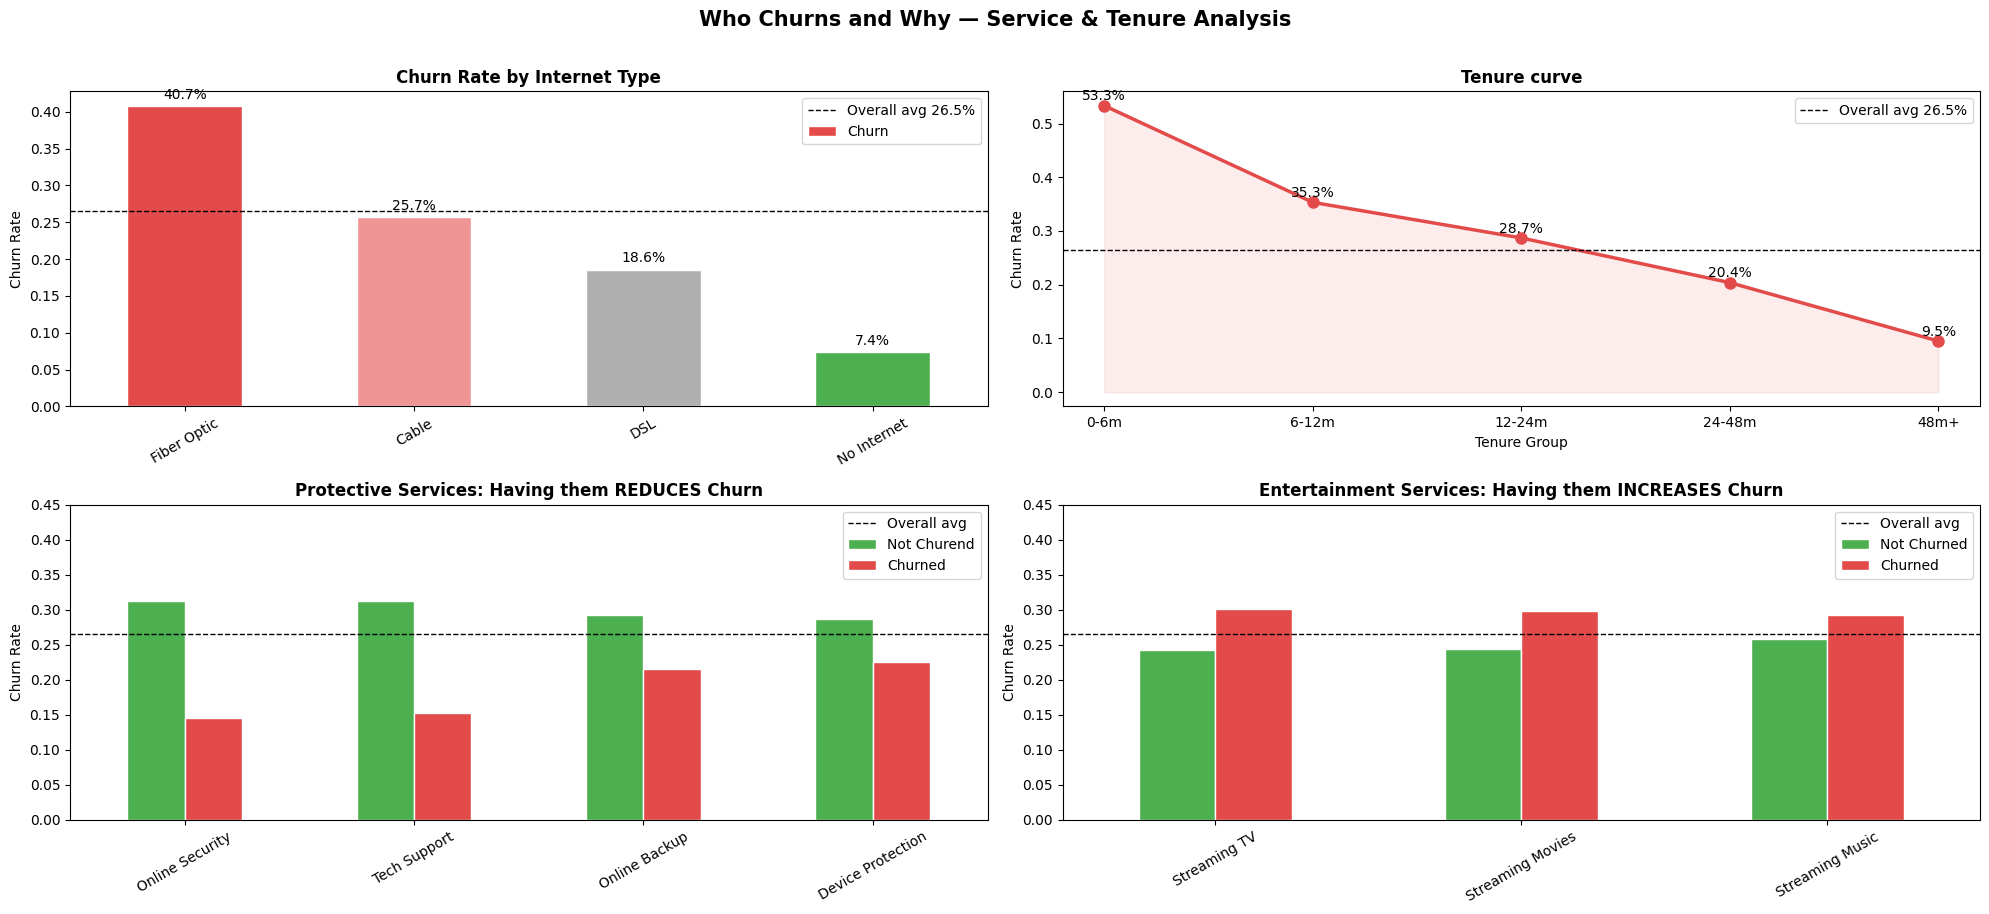

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(20, 9))

# Internet Type
internet_churn = df.groupby('Internet Type', observed=False)['Churn'].mean().sort_values(ascending=False)

colors_internet = ['#E24B4A', '#F09595', '#B0B0B0', '#4CAF50']
internet_churn.plot(kind='bar', ax=axes[0,0], color=colors_internet, edgecolor='white')
axes[0,0].set_title('Churn Rate by Internet Type',
                     fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Churn Rate')
axes[0,0].set_xlabel('')
axes[0,0].axhline(y=0.265, color='black', linestyle='--',
                   linewidth=1, label='Overall avg 26.5%')
axes[0,0].legend()
axes[0,0].tick_params(axis='x', rotation=30)
for i, v in enumerate(internet_churn):
    axes[0,0].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=10)


# Tenure Curve
df['Tenure Group'] = pd.cut(df['Tenure in Months'],
                             bins=[0, 6, 12, 24, 48, 100],
                             labels=['0-6m', '6-12m', '12-24m', '24-48m', '48m+'])
tenure_churn = df.groupby('Tenure Group', observed=False)['Churn'].mean()

axes[0,1].plot(range(len(tenure_churn)), tenure_churn.values,
               marker='o', color='#E24B4A', linewidth=2.5, markersize=8)
axes[0,1].fill_between(range(len(tenure_churn)), tenure_churn.values,
                        alpha=0.1, color='#E24B4A')
axes[0,1].set_title('Tenure curve',
                     fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Churn Rate')
axes[0,1].set_xlabel('Tenure Group')
axes[0,1].set_xticks(range(len(tenure_churn)))
axes[0,1].set_xticklabels(tenure_churn.index)
axes[0,1].axhline(y=0.265, color='black', linestyle='--',
                   linewidth=1, label='Overall avg 26.5%')
axes[0,1].legend()
for i, v in enumerate(tenure_churn.values):
    axes[0,1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=10)


# Protective Services
protective_avg = {
    'Online Security':   [0.313, 0.146],
    'Tech Support':      [0.312, 0.152],
    'Online Backup':     [0.292, 0.215],
    'Device Protection': [0.287, 0.225]
}
protective_df = pd.DataFrame(protective_avg, index=['No', 'Yes']).T
protective_df.plot(kind='bar', ax=axes[1,0],
                   color=['#4CAF50', '#E24B4A'], edgecolor='white')
axes[1,0].set_title('Protective Services: Having them REDUCES Churn',
                     fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Churn Rate')
axes[1,0].set_xlabel('')
axes[1,0].set_ylim(0, 0.45)
axes[1,0].axhline(y=0.265, color='black', linestyle='--',
                   linewidth=1, label='Overall avg 26.5%')
axes[1,0].legend(['Overall avg', 'Not Churend', 'Churned'])
axes[1,0].tick_params(axis='x', rotation=30)


# Entertainment Services
entertainment_avg = {
    'Streaming TV':     [0.243, 0.301],
    'Streaming Movies': [0.244, 0.299],
    'Streaming Music':  [0.258, 0.293]
}
entertainment_df = pd.DataFrame(entertainment_avg, index=['No', 'Yes']).T
entertainment_df.plot(kind='bar', ax=axes[1,1],
                      color=['#4CAF50', '#E24B4A'], edgecolor='white')
axes[1,1].set_title('Entertainment Services: Having them INCREASES Churn',
                     fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Churn Rate')
axes[1,1].set_xlabel('')
axes[1,1].set_ylim(0, 0.45)
axes[1,1].axhline(y=0.265, color='black', linestyle='--',
                   linewidth=1, label='Overall avg 26.5%')
axes[1,1].legend(['Overall avg', 'Not Churned', 'Churned'])
axes[1,1].tick_params(axis='x', rotation=30)


# Final layout
plt.suptitle('Who Churns and Why — Service & Tenure Analysis',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_service_tenure_churn.png', dpi=150, bbox_inches='tight')
plt.show()

Key takeaway: Contract type and tenure drive structural churn risk.

Protective services act as loyalty anchors customers with
Online Security churn at half the rate of those without.

Entertainment services show the opposite effect.

# 3. What's the financial profile of Churned customers? (Finance)

In [65]:
# Monthly Charge distribution: Churned vs Stayed
churned = df[df['Churn'] == 1]['Monthly Charge']
stayed  = df[df['Churn'] == 0]['Monthly Charge']

print("Churned - Monthly Charge:")
print(churned.describe().round(2))
print("\nStayed - Monthly Charge:")
print(stayed.describe().round(2))

Churned - Monthly Charge:
count    1869.00
mean       74.44
std        24.67
min        18.85
25%        56.15
50%        79.65
75%        94.20
max       118.35
Name: Monthly Charge, dtype: float64

Stayed - Monthly Charge:
count    5174.00
mean       61.27
std        31.09
min        18.25
25%        25.10
50%        64.43
75%        88.40
max       118.75
Name: Monthly Charge, dtype: float64


Churned customers pay USD 74.44 per month on average vs USD 61.27
for retained customers — a USD 13.17 gap.

**Highest paying customers are leaving.**
This means churn isn't a budget customer problem.

It's a value perception problem.
They're paying more but not feeling they get more.

In [66]:
# CLTV distribution: Churned vs Stayed
churned_cltv = df[df['Churn'] == 1]['CLTV']
stayed_cltv  = df[df['Churn'] == 0]['CLTV']

print("Churned - CLTV:")
print(churned_cltv.describe().round(2))
print("\nStayed - CLTV:")
print(stayed_cltv.describe().round(2))

Churned - CLTV:
count    1869.00
mean     4149.41
std      1189.37
min      2003.00
25%      3101.00
50%      4238.00
75%      5166.00
max      6484.00
Name: CLTV, dtype: float64

Stayed - CLTV:
count    5174.00
mean     4490.92
std      1167.70
min      2003.00
25%      3643.75
50%      4620.00
75%      5434.75
max      6500.00
Name: CLTV, dtype: float64


Churned avg CLTV: USD 4,149 vs Stayed: USD 4,491 — only USD 342 gap.

Interestingly the CLTV gap is relatively small.

**Churned customers WERE valuable customers**

→ Not low-value customers self-selecting out

→ The company is losing people that should be keeping

→ Retention effort is fully justified financially

In [67]:
# Total Revenue lost by churn category
revenue_by_category = df[df['Churn'] == 1].groupby('Churn Category')['Total Revenue'].agg(['sum', 'mean', 'count'])
revenue_by_category.columns = ['Total Revenue Lost', 'Avg Revenue per Customer', 'Customer Count']
revenue_by_category = revenue_by_category.sort_values('Total Revenue Lost', ascending=False)
print(revenue_by_category.round(2))

                 Total Revenue Lost  Avg Revenue per Customer  Customer Count
Churn Category                                                               
Competitor               1694413.15                   2014.76             841
Dissatisfaction           583584.72                   1926.02             303
Attitude                  579554.13                   1845.71             314
Price                     438124.14                   2076.42             211
Other                     388783.68                   1943.92             200


46% of USD 3.7M revenue loss - USD 1.69M - is going directly to competitors.

This is not a satisfaction problem but **a competitive positioning problem.**

In [68]:
# Monthly Charge vs Tenure by Churn
print("\nAvg Monthly Charge by Tenure Group:")
print(df.groupby(['Tenure Group', 'Churn'], observed=False)['Monthly Charge'].mean().round(2))


Avg Monthly Charge by Tenure Group:
Tenure Group  Churn
0-6m          0        44.78
              1        63.64
6-12m         0        49.59
              1        75.33
12-24m        0        54.45
              1        78.51
24-48m        0        61.17
              1        84.50
48m+          0        72.03
              1        92.17
Name: Monthly Charge, dtype: float64


Consistent pattern across every tenure group.

Churned customers always pay significantly more than those who stayed.
This completely rules out price sensitivity as the primary churn driver.

Customers are not leaving because of high charges **they are leaving because they don't feel the value matches the price**.

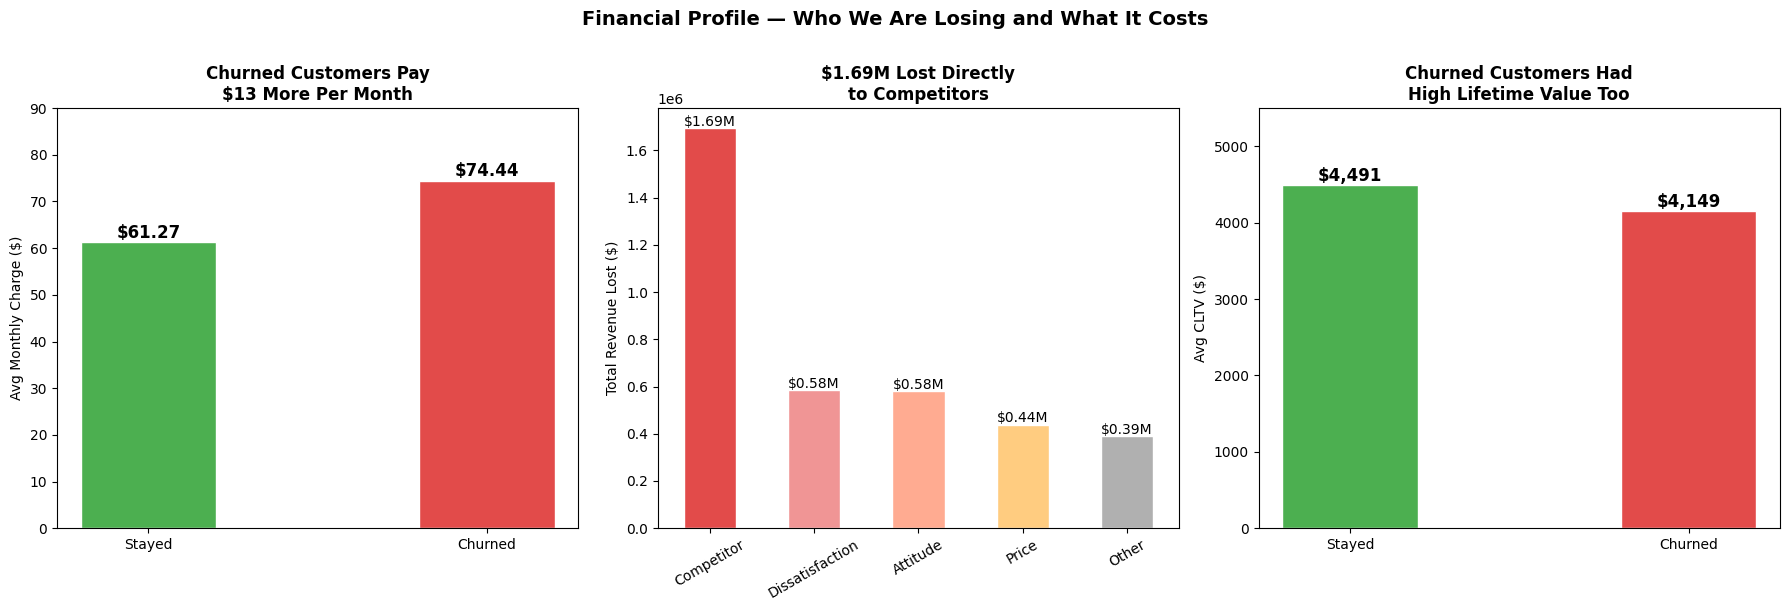

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Chart 1: Monthly Charge distribution
monthly_summary = pd.DataFrame({
    'Group': ['Stayed', 'Churned'],
    'Avg Monthly Charge': [61.27, 74.44]
})

axes[0].bar(monthly_summary['Group'],
            monthly_summary['Avg Monthly Charge'],
            color=['#4CAF50', '#E24B4A'],
            edgecolor='white', width=0.4)
axes[0].set_ylim(0, 90)
axes[0].set_title('Churned Customers Pay\n$13 More Per Month',
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('Avg Monthly Charge ($)')
for i, v in enumerate([61.27, 74.44]):
    axes[0].text(i, v + 1, f'${v}', ha='center',
                 fontsize=12, fontweight='bold')

# Chart 2: Revenue lost by Churn Category
colors_cat = ['#E24B4A', '#F09595', '#FFAB91', '#FFCC80', '#B0B0B0']
revenue_by_category['Total Revenue Lost'].plot(
    kind='bar', ax=axes[1], color=colors_cat, edgecolor='white')
axes[1].set_title('$1.69M Lost Directly\nto Competitors',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Total Revenue Lost ($)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(revenue_by_category['Total Revenue Lost']):
    axes[1].text(i, v + 10000, f'${v/1e6:.2f}M',
                 ha='center', fontsize=10)

# Chart 3: CLTV comparison — Stayed vs Churned
cltv_summary = pd.DataFrame({
    'Group': ['Stayed', 'Churned'],
    'Avg CLTV': [4490.92, 4149.41]
})

axes[2].bar(cltv_summary['Group'],
            cltv_summary['Avg CLTV'],
            color=['#4CAF50', '#E24B4A'],
            edgecolor='white', width=0.4)
axes[2].set_ylim(0, 5500)
axes[2].set_title('Churned Customers Had\nHigh Lifetime Value Too',
                   fontsize=12, fontweight='bold')
axes[2].set_ylabel('Avg CLTV ($)')
for i, v in enumerate([4490.92, 4149.41]):
    axes[2].text(i, v + 50, f'${v:,.0f}',
                 ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Financial Profile — Who We Are Losing and What It Costs',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('financial_churn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

1. Churned customers pay USD 13 more per month than
   those who stay — this is a value gap, not a price gap.

2. USD 1.69M of the USD 3.7M revenue loss flows directly to competitors which demands a competitive response.

3. CLTV of churned customers matches retained ones —
   these are worth fighting for.

# Prediction Modelling

In [70]:
# Strong signals reasoning
high_signal = [
    'Contract',              # strongest structural predictor
    'Tenure in Months',      # early customers most vulnerable
    'Internet Type',         # Fiber Optic highest risk segment
    'Online Security',       # protective service effect
    'Premium Tech Support',  # protective service effect
    'Monthly Charge',        # churners pay more
    'Satisfaction Score',    # later identified as leaky feature
    'Senior Citizen',        # elevated churn rate
]

# Weak signals (to drop) reasoning
low_signal = [
    'Phone Service',       # negligible difference
    'Multiple Lines',      # negligible difference
    'Gender',              # unlikely to matter
    'Country', 'State',    # all California in this dataset
]

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

# Select features
features = [
    'Contract', 'Tenure in Months', 'Internet Type',
    'Online Security', 'Premium Tech Support', 'Online Backup',
    'Device Protection Plan', 'Streaming TV', 'Streaming Movies',
    'Streaming Music', 'Monthly Charge', 'Satisfaction Score',
    'Senior Citizen', 'Married', 'Age', 'Number of Referrals',
    'Paperless Billing', 'Payment Method', 'Offer'
]

target = 'Churn'

# Copy working dataframe
model_df = df[features + [target]].copy()

# Check dtypes
print(model_df.dtypes)
print("\nShape:", model_df.shape)
print("Churn distribution:\n", model_df[target].value_counts())

Contract                   object
Tenure in Months            int64
Internet Type              object
Online Security            object
Premium Tech Support       object
Online Backup              object
Device Protection Plan     object
Streaming TV               object
Streaming Movies           object
Streaming Music            object
Monthly Charge            float64
Satisfaction Score          int64
Senior Citizen             object
Married                    object
Age                         int64
Number of Referrals         int64
Paperless Billing          object
Payment Method             object
Offer                      object
Churn                       int64
dtype: object

Shape: (7043, 20)
Churn distribution:
 Churn
0    5174
1    1869
Name: count, dtype: int64


In [72]:
# Binary columns → 0/1
binary_cols = [
    'Online Security', 'Premium Tech Support', 'Online Backup',
    'Device Protection Plan', 'Streaming TV', 'Streaming Movies',
    'Streaming Music', 'Married', 'Paperless Billing', 'Senior Citizen'
]

for col in binary_cols:
    model_df[col] = model_df[col].map({'Yes': 1, 'No': 0})

# Multi-category columns → One Hot Encode
multi_cols = ['Contract', 'Internet Type', 'Payment Method', 'Offer']
model_df = pd.get_dummies(model_df, columns=multi_cols, drop_first=False)

# Verify
print("Shape after encoding:", model_df.shape)
print("\nAny nulls?", model_df.isnull().sum().sum())
print("\nSample columns:", list(model_df.columns))

Shape after encoding: (7043, 32)

Any nulls? 0

Sample columns: ['Tenure in Months', 'Online Security', 'Premium Tech Support', 'Online Backup', 'Device Protection Plan', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Monthly Charge', 'Satisfaction Score', 'Senior Citizen', 'Married', 'Age', 'Number of Referrals', 'Paperless Billing', 'Churn', 'Contract_Month-to-Month', 'Contract_One Year', 'Contract_Two Year', 'Internet Type_Cable', 'Internet Type_DSL', 'Internet Type_Fiber Optic', 'Internet Type_No Internet', 'Payment Method_Bank Withdrawal', 'Payment Method_Credit Card', 'Payment Method_Mailed Check', 'Offer_No Offer', 'Offer_Offer A', 'Offer_Offer B', 'Offer_Offer C', 'Offer_Offer D', 'Offer_Offer E']


In [73]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb

print("All imports successful")

# Define X and y (with Satisfaction Score Included)
X_leaky = model_df.drop(columns=['Churn'])
y = model_df['Churn']

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_leaky, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scale = (y_train_l == 0).sum() / (y_train_l == 1).sum()

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42))
    ]),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5,
        class_weight='balanced',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        class_weight='balanced',
        random_state=42
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=scale,
        random_state=42,
        eval_metric='auc'
    )
}

# Initial Model Comparison
print("=" * 55)
print("SECTION 4.1 — Initial Model Comparison")
print("=" * 55)

leaky_results = {}

for name, m in models.items():
    cv_scores = cross_val_score(
        m, X_train_l, y_train_l,
        cv=5, scoring='roc_auc'
    )
    m.fit(X_train_l, y_train_l)
    y_prob = m.predict_proba(X_test_l)[:, 1]
    test_auc = roc_auc_score(y_test_l, y_prob)

    leaky_results[name] = {
        'CV AUC (mean)': cv_scores.mean().round(4),
        'CV AUC (std)':  cv_scores.std().round(4),
        'Test AUC':      round(test_auc, 4)
    }

    print(f"{name}")
    print(f"  CV AUC:   {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Test AUC: {test_auc:.4f}\n")

leaky_df = pd.DataFrame(leaky_results).T.sort_values(
    'Test AUC', ascending=False)
print("Summary:")
print(leaky_df)

All imports successful
SECTION 4.1 — Initial Model Comparison
Logistic Regression
  CV AUC:   0.9917 ± 0.0015
  Test AUC: 0.9905

Decision Tree
  CV AUC:   0.9864 ± 0.0019
  Test AUC: 0.9845

Random Forest
  CV AUC:   0.9832 ± 0.0037
  Test AUC: 0.9760

XGBoost
  CV AUC:   0.9922 ± 0.0018
  Test AUC: 0.9906

Summary:
                     CV AUC (mean)  CV AUC (std)  Test AUC
XGBoost                     0.9922        0.0018    0.9906
Logistic Regression         0.9917        0.0015    0.9905
Decision Tree               0.9864        0.0019    0.9845
Random Forest               0.9832        0.0037    0.9760


 All models show suspiciously high AUC → Suspiciously high for real-world churn problem.

Investigation is needed before proceeding.

A score this high typically indicates data leakage a feature that contains information about the outcome that would not be available at prediction time.

In [74]:
# Leakage Investigation
print("=" * 55)
print("SECTION 4.2 — Leakage Investigation")
print("=" * 55)

# Correlation of every feature with Churn
correlations = model_df.corr()['Churn'].abs().sort_values(ascending=False)

print("Top 10 features correlated with Churn:")
print(correlations.head(10))

SECTION 4.2 — Leakage Investigation
Top 10 features correlated with Churn:
Churn                         1.000000
Satisfaction Score            0.754649
Contract_Month-to-Month       0.448427
Tenure in Months              0.352861
Contract_Two Year             0.328195
Number of Referrals           0.286540
Internet Type_Fiber Optic     0.279623
Internet Type_No Internet     0.227890
Payment Method_Credit Card    0.218528
Offer_Offer E                 0.214648
Name: Churn, dtype: float64


Leakage confirmed
'Satisfaction Score' shows a correlation
of 0.75 with Churn, far higher than any other feature

whilst the next highest legitimate feature (Contract_Month-to-Month) is only 0.45

**Satisfaction Score is collected at the point of the customers decide to leave.**

In [75]:
# Clean Model Comparison
print("=" * 55)
print("(Satisfaction Score removed)")
print("=" * 55)

X_clean = model_df.drop(columns=['Churn', 'Satisfaction Score'])
y = model_df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scale = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42))
    ]),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5,
        class_weight='balanced',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        class_weight='balanced',
        random_state=42
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=scale,
        random_state=42,
        eval_metric='auc'
    )
}

clean_results = {}

for name, m in models.items():
    cv_scores = cross_val_score(
        m, X_train, y_train,
        cv=5, scoring='roc_auc'
    )
    m.fit(X_train, y_train)
    y_prob = m.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_prob)

    clean_results[name] = {
        'CV AUC (mean)': cv_scores.mean().round(4),
        'CV AUC (std)':  cv_scores.std().round(4),
        'Test AUC':      round(test_auc, 4)
    }

    print(f"{name}")
    print(f"  CV AUC:   {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Test AUC: {test_auc:.4f}\n")

clean_df = pd.DataFrame(clean_results).T.sort_values(
    'Test AUC', ascending=False)
print("Summary:")
print(clean_df)

(Satisfaction Score removed)
Logistic Regression
  CV AUC:   0.8918 ± 0.0040
  Test AUC: 0.8921

Decision Tree
  CV AUC:   0.8689 ± 0.0101
  Test AUC: 0.8693

Random Forest
  CV AUC:   0.8908 ± 0.0041
  Test AUC: 0.8860

XGBoost
  CV AUC:   0.8999 ± 0.0040
  Test AUC: 0.9009

Summary:
                     CV AUC (mean)  CV AUC (std)  Test AUC
XGBoost                     0.8999        0.0040    0.9009
Logistic Regression         0.8918        0.0040    0.8921
Random Forest               0.8908        0.0041    0.8860
Decision Tree               0.8689        0.0101    0.8693


              precision    recall  f1-score   support

      Stayed       0.93      0.79      0.86      1035
     Churned       0.60      0.84      0.70       374

    accuracy                           0.81      1409
   macro avg       0.76      0.82      0.78      1409
weighted avg       0.84      0.81      0.82      1409



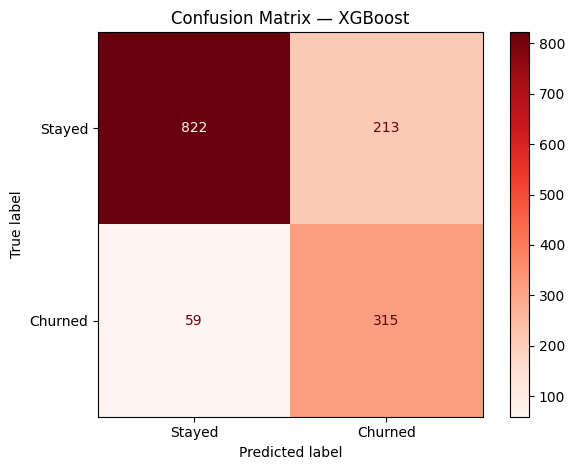

In [76]:
from sklearn.metrics import ConfusionMatrixDisplay
import shap

# Final model predictions
xgb_model = models['XGBoost']

y_pred      = xgb_model.predict(X_test)
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]

# Classification Report
print(classification_report(y_test, y_pred,
      target_names=['Stayed', 'Churned']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Stayed', 'Churned'])
disp.plot(cmap='Reds')
plt.title('Confusion Matrix — XGBoost')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Recall (Churned) = 0.84

→ Catches 84% of actual churners

→ 315 out of 374 at-risk customers flagged

→ Only 59 churners missed completely

Precision (Churned) = 0.60

→ Of everyone we flag as churner, 60% actually churn

→ 213 customers incorrectly flagged (false alarms)

Is 0.60 precision a problem?

Cost of false alarm:

→ Offer a retention deal to someone
  who wasn't leaving

→ Small cost: discount or a phone call

Cost of missing a churner (59 customers):

→ Lost revenue permanently

59 missed churners × avg monthly charge × avg tenure
= significant lost revenue

213 false alarms × assumed retention offer cost (~USD 20)
= ~USD 4,260

→ The model saves significantly more than it costs

→ 0.60 precision is acceptable in this context


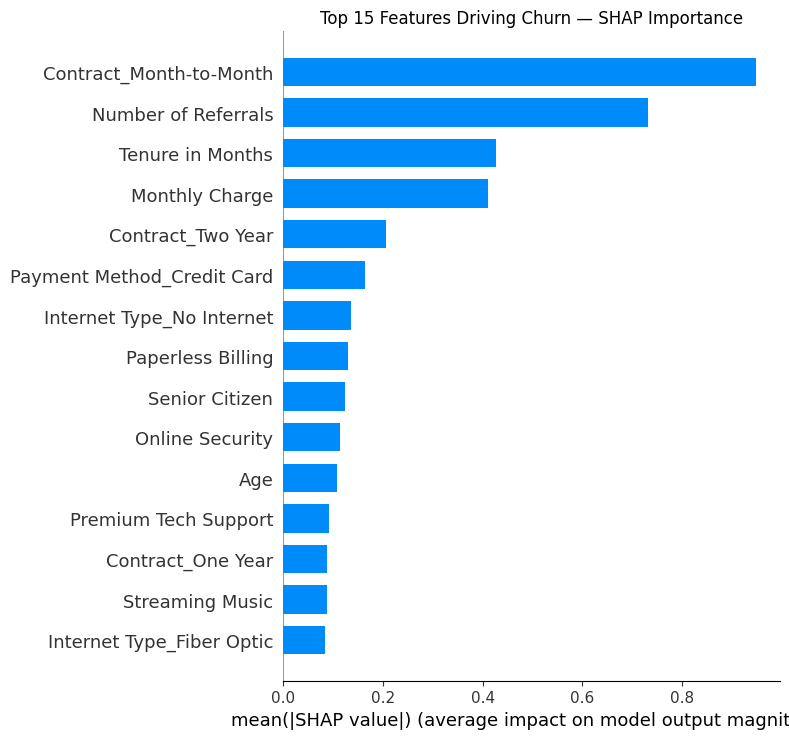

In [77]:
import shap

# SHAP Values
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test,
                  plot_type='bar',
                  max_display=15,
                  show=False)
plt.title('Top 15 Features Driving Churn — SHAP Importance')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

Contract_Month-to-Month is by far the #1 churn driver —
confirming our EDA finding that M2M customers churn at 45.8%.

Number of Referrals is the #2 driver — surprisingly strong
and not immediately obvious from EDA alone.

Customers who refer
friends are significantly more loyal — referrals signal
deep engagement with the product.


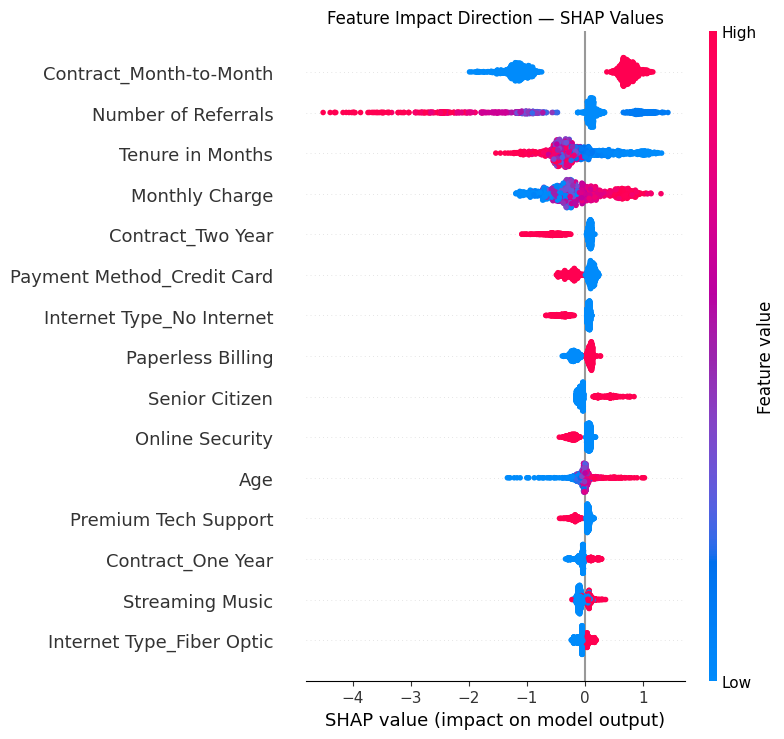

In [78]:
# SHAP Dot Plot (shows direction of impact)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test,
                  max_display=15,
                  show=False)
plt.title('Feature Impact Direction — SHAP Values')
plt.tight_layout()
plt.savefig('shap_dot.png', dpi=150, bbox_inches='tight')
plt.show()

**Key finding:**

Number of Referrals shows the strongest *range* of impact (SHAP spread from –4 to +1.5), yet was underweighted in EDA. This is SHAP surfacing non-linear signal.

**Business implication:**

- High referrers → strong negative churn probability → referral program is a *retention* lever, not just acquisition

- Contract_Month-to-Month: high feature value (red) pushes churn probability UP as expected

- Tenure & Monthly Charge cluster tightly near 0 → moderate, consistent effect

In [79]:
import joblib

# Save model
joblib.dump(xgb_model, 'churn_model.pkl')

# Save feature column names
feature_cols = X_train.columns.tolist()
joblib.dump(feature_cols, 'feature_cols.pkl')

# Save SHAP explainer
joblib.dump(explainer, 'shap_explainer.pkl')

print("Saved:")
print("  churn_model.pkl")
print("  feature_cols.pkl")
print("  shap_explainer.pkl")
print("\nFeature count:", len(feature_cols))
print("Features:", feature_cols)

Saved:
  churn_model.pkl
  feature_cols.pkl
  shap_explainer.pkl

Feature count: 30
Features: ['Tenure in Months', 'Online Security', 'Premium Tech Support', 'Online Backup', 'Device Protection Plan', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Monthly Charge', 'Senior Citizen', 'Married', 'Age', 'Number of Referrals', 'Paperless Billing', 'Contract_Month-to-Month', 'Contract_One Year', 'Contract_Two Year', 'Internet Type_Cable', 'Internet Type_DSL', 'Internet Type_Fiber Optic', 'Internet Type_No Internet', 'Payment Method_Bank Withdrawal', 'Payment Method_Credit Card', 'Payment Method_Mailed Check', 'Offer_No Offer', 'Offer_Offer A', 'Offer_Offer B', 'Offer_Offer C', 'Offer_Offer D', 'Offer_Offer E']


In [80]:
from google.colab import files
files.download('churn_model.pkl')
files.download('feature_cols.pkl')
files.download('shap_explainer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>